## Prática para Entrega: Modelo de Hopfield e BAM
Implementação e teste da rede BAM



1. Crie uma matriz com a representação -1/1 dos dígitos 0, 1, 2, 3, 4, 5, 6, 7, 8 e 9 do conjunto de dados MNIST

2. Crie uma matriz na qual as linhas representam os vetores de saída com a representação -1/1 para cada dígito

3. Execute a rede BAM nesses dados e verifique se os dígitos originais são recuperados corretamente
4. Faça variações nos vetores de dígitos originais, execute a rede BAM, e verifique se os dígitos são recuperados corretamente
5. Compare com a rede de Hopfield vista em aula



In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

### Carregar a base de dados - dataset MNIST

In [25]:
def carregando_MNIST(num_desejados):
    mnist =  fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist.data, mnist.target.astype(int)

    padroes_treino = []

    for elem in num_desejados:
        indice = np.where(y == elem)[0][0] #pega a 1° ocoreencia de cada num desejado
        #converte a img -> pixels > 127 vira 1, e restante -1
        img_formatada = np.where(X[indice] > 127, 1, -1)
        padroes_treino.append(img_formatada)

    return np.array(padroes_treino)


In [26]:
padroes = carregando_MNIST(np.array([0]))
print(padroes[:, 0:28])

[[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1]]


### Função Saída Bipolar(-1,1)

matriz na qual as linhas representam os vetores de saída com a representação -1/1 para cada dígito

In [27]:
def matriz_saida( num_desejado):
    #teremos uma matriz num,10
    num = num_desejado.shape[0]
    matriz_saida = -np.ones((num,10))
   

    for i in range(num):
        idx =  (num_desejado[i])
        matriz_saida[i,idx] = 1
    return matriz_saida



In [28]:
print(matriz_saida(np.array([1,3,9,2])))

[[-1.  1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [-1. -1. -1.  1. -1. -1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1. -1. -1. -1. -1.  1.]
 [-1. -1.  1. -1. -1. -1. -1. -1. -1. -1.]]


### Implementação da Rede BAM

Função Ativação => similar a função sign, e limita os valores entre -1,1
seguindo a logica:
$$
\operatorname{funcAtivacao}(v) =
\begin{cases}
+1, & v > 0 \\
-1, & v < 0 \\
sorteio, \text{caso contrário}
\end{cases}
$$

In [29]:
def funcao_ativacao(v):
    #se o elem de v for < 0, troca por -1. caso contrario, +1
    result =  np.where(v < 0, -1, 1)

    #caso seja 0, sorteio aleatorio dos elem -1,1
    zeros = (v ==0)
    result[zeros] = np.random.choice([-1,1], size=zeros.sum())
    return result

BAM_Armazenamento(X,y) => calcula o produto externo das matriz X e Y e as retorna na matriz pesos

In [30]:
def bam_armazenamento(X,y):
    #dimensoes de x e y
    nlinX, ncolX =  X.shape
    _, ncoly =  y.shape
    
    pesos = np.zeros((ncolX, ncoly))

    for i in range(nlinX):
        pesos = pesos + np.outer(X[i,:] ,y[i,])
        
     
    return(pesos)

BAM_Teste(M, x): tenta recuperar os padroes interando os espaços dados por X-Y ate a rede convergir. Para isso, usa a entropia de Shannon pra como criterio de parada 

In [31]:
def bam_teste(M, x):
    entropia_antigo = 100
    delta_entrop = 1
    
    while(delta_entrop > 0):
        #em direcao a y
        sx = x @ M
        sx = funcao_ativacao(sx)

        #calculo da entropia - valor menor, menos confusao - melhor
        entropia = float(-(x @ M @ sx))

        #em direcao a x
        x = funcao_ativacao(M @ sx)

        #varicao da entropia
        delta_entrop = abs(entropia - entropia_antigo)
        entropia_antigo = entropia

        print("\nVaricao na Entropia =  ", delta_entrop)

        

    print(f"| Saída: {sx} \n Entrada: {x}")
    return sx


#### Testando utilizando  abase MNIST

Carregando os numeros

In [32]:
numeros  = np.array([7])

padroes = carregando_MNIST(numeros)

saida =  matriz_saida(numeros)

armazenando os padroes na rede

In [33]:
M = bam_armazenamento(padroes, saida)


usando os mesmos padroes para teste

In [34]:

bam_teste(M, padroes[0])



Varicao na Entropia =   7940.0

Varicao na Entropia =   0.0
| Saída: [-1 -1 -1 -1 -1 -1 -1  1 -1 -1] 
 Entrada: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1
  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  1  1  1  

array([-1, -1, -1, -1, -1, -1, -1,  1, -1, -1])

In [35]:
#testando o sentido contrario
teste = bam_teste(M.T, saida[0])


Varicao na Entropia =   7940.0

Varicao na Entropia =   0.0
| Saída: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1
  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  1  1  1  1  1  1 -1 -1 -1 -1  1  1  1  1 -1 -1 -1 -1

#### Testando as redes com outros tipos de padroes


In [36]:
# Padrões X (3 neurônios)
X = np.array([
    [ 1, -1,  1],
    [-1,  1, -1]
])

# Padrões Y (2 neurônios)
Y = np.array([
    [ 1,  1],
    [-1, -1]
])

In [37]:
W = bam_armazenamento(X, Y)
print("Matriz de pesos:\n", W)

Matriz de pesos:
 [[ 2.  2.]
 [-2. -2.]
 [ 2.  2.]]


In [38]:
# Teste com padrão conhecido
x_teste = np.array([1, -1, 1])

y_rec = bam_teste(W, x_teste)
print("Saída recuperada:", y_rec)


Varicao na Entropia =   112.0

Varicao na Entropia =   0.0
| Saída: [1 1] 
 Entrada: [ 1 -1  1]
Saída recuperada: [1 1]


In [39]:
# Um bit errado
x_ruido = np.array([1, -1, -1])

y_rec = bam_teste(W, x_ruido)
print("Saída com ruído:", y_rec)


Varicao na Entropia =   104.0

Varicao na Entropia =   8.0

Varicao na Entropia =   0.0
| Saída: [1 1] 
 Entrada: [ 1 -1  1]
Saída com ruído: [1 1]


In [40]:
#testando o sentido contrario
y_teste = np.array([1, 1])

x_rec = bam_teste(W.T, y_teste)
print("Entrada recuperada:", x_rec)


Varicao na Entropia =   112.0

Varicao na Entropia =   0.0
| Saída: [ 1 -1  1] 
 Entrada: [1 1]
Entrada recuperada: [ 1 -1  1]


### Implementação da rede do tipo Hopfield

In [41]:
# --- 2. FUNÇÕES DA REDE DE HOPFIELD ---

def treinar_hopfield(padroes):
    """
    Regra de Hebb: W = (1/N) * sum(p * p.T)
    """
    n_padroes, n_nos = padroes.shape
    W = np.zeros((n_nos, n_nos))

    for p in padroes:
        W += np.outer(p, p)

    W = W / n_nos
    np.fill_diagonal(W, 0) # Garante que não haja auto-feedback
    return W

def calcular_energia(x, W):
    """Calcula a energia da rede para o estado atual x"""
    return -0.5 * np.dot(x.T, np.dot(W, x))

def recuperar_padrao_com_energia(y_inicial, W, maxit=20000):
    n_nos = len(y_inicial)
    y = y_inicial.copy().astype(float)
    converge = False
    ordem = np.arange(n_nos)

    # Lista para guardar a energia ao longo do tempo
    historico_energia = []

    for it in range(maxit):
        # Registra a energia no início de cada iteração (ou a cada N iterações)
        # Para o MNIST, registrar a cada pixel pode ser lento,
        # então registramos a cada 10 pixels ou a cada época.
        if it % 10 == 0:
            historico_energia.append(calcular_energia(y, W))

        if it % n_nos == 0:
            if it > 0 and converge:
                print(f"Alcançou estado estável na iteração {it}")
                break
            ordem = np.random.permutation(n_nos)
            converge = True

        i = ordem[it % n_nos]
        yi_old = y[i]

        v = np.dot(W[i, :], y)

        if v > 0:
            y[i] = 1
        elif v < 0:
            y[i] = -1

        if yi_old != y[i]:
            converge = False

    return y, historico_energia

In [42]:
# --- 3. FUNÇÃO DE RUÍDO (A que causa a inversão) ---

def adicionar_ruido_bipolar(imagem, percentual=0.1):
    """
    Troca 1 por -1 e vice-versa baseado num percentual.
    Se percentual > 0.5, a rede tende a convergir para o inverso!
    """
    resultado = imagem.copy()
    n_pixels = len(imagem)
    indices = np.random.choice(n_pixels, int(n_pixels * percentual), replace=False)
    resultado[indices] *= -1 # Inverte o sinal
    return resultado

In [43]:
# --- 4. EXECUÇÃO DO EXPERIMENTO ---

# 1. Preparar dados
#padroes = carregando_MNIST([0, 1, 3, 9])
W = treinar_hopfield(padroes)

# 2. Criar teste com ruído. Se colocar muito (por exemplo 60%), da pra ver a inversão
img_original = padroes[0]
img_ruidosa = adicionar_ruido_bipolar(img_original, percentual=0.1)

# 3. Recuperar (maxit deve ser grande para cobrir 784 neurônios várias vezes)
img_recuperada, energias = recuperar_padrao_com_energia(img_ruidosa, W, maxit=784*20)

Alcançou estado estável na iteração 1568


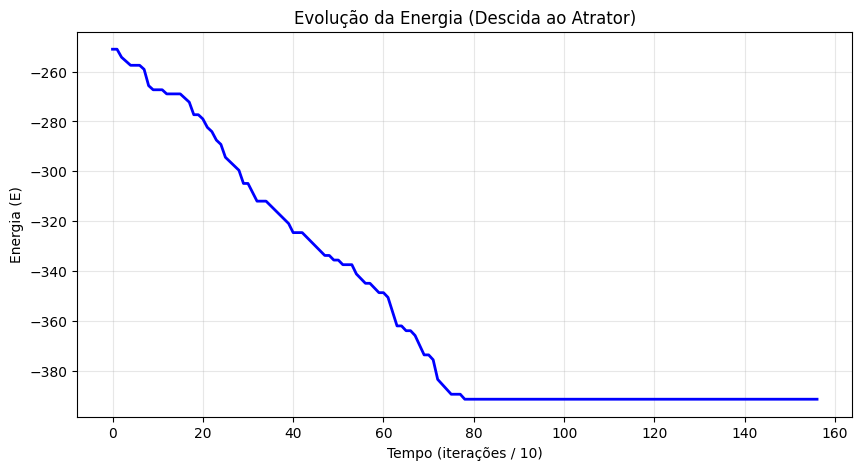

In [44]:
# 4. Plotar o comportamento da Energia
plt.figure(figsize=(10, 5))
plt.plot(energias, color='blue', linewidth=2)
plt.title("Evolução da Energia (Descida ao Atrator)")
plt.xlabel("Tempo (iterações / 10)")
plt.ylabel("Energia (E)")
plt.grid(True, alpha=0.3)
plt.show()

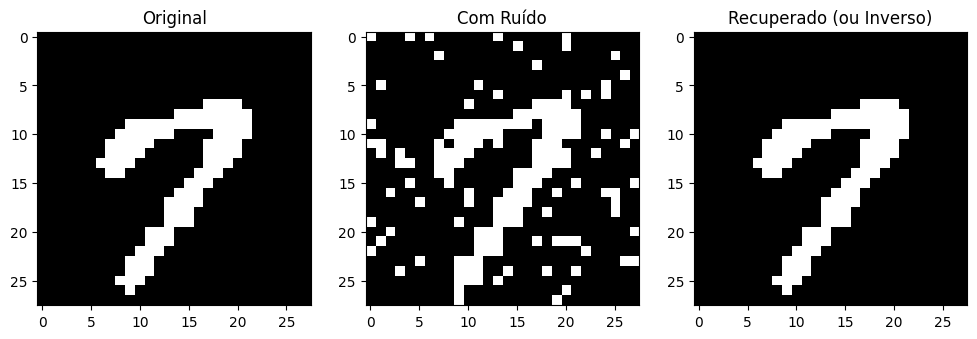

In [45]:

# 5. Visualização
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_original.reshape(28, 28), cmap='gray')
ax[0].set_title("Original")
ax[1].imshow(img_ruidosa.reshape(28, 28), cmap='gray')
ax[1].set_title("Com Ruído")
ax[2].imshow(img_recuperada.reshape(28, 28), cmap='gray')
ax[2].set_title("Recuperado (ou Inverso)")
plt.show()